In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
allegations = pd.read_csv('nypd_data/allegations.csv')

In [4]:
allegations.groupby('mos_ethnicity').size().sort_values(ascending=False)

mos_ethnicity
White              18074
Hispanic            9150
Black               4924
Asian               1178
American Indian       32
dtype: int64

In [5]:
allegations.groupby('complainant_ethnicity').size().sort_values(ascending=False)

complainant_ethnicity
Black              17114
Hispanic            6424
White               2783
Unknown             1041
Other Race           677
Asian                532
Refused              259
American Indian       64
dtype: int64

In [6]:
allegations.columns

Index(['unique_mos_id', 'first_name', 'last_name', 'command_now', 'shield_no',
       'complaint_id', 'month_received', 'year_received', 'month_closed',
       'year_closed', 'command_at_incident', 'rank_abbrev_incident',
       'rank_abbrev_now', 'rank_now', 'rank_incident', 'mos_ethnicity',
       'mos_gender', 'mos_age_incident', 'complainant_ethnicity',
       'complainant_gender', 'complainant_age_incident', 'fado_type',
       'allegation', 'precinct', 'contact_reason', 'outcome_description',
       'board_disposition'],
      dtype='object')

In [7]:
allegations[allegations['complainant_ethnicity'] == 'Black']

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
12,10026,Brian,Alexander,079 DET,3185,35092,5,2016,10,2016,...,30,Black,Male,30.0,Abuse of Authority,Search (of person),79.0,Moving violation,No arrest made or summons issued,Unsubstantiated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33341,9975,Inna,Miroshnyk,078 PCT,4042,42328,5,2019,10,2019,...,32,Black,Male,33.0,Abuse of Authority,Refusal to provide name,78.0,Other violation of VTL,Other VTL violation summons issued,Substantiated (Command Lvl Instructions)
33348,9984,Hassan,Paris,078 PCT,10125,42835,7,2019,5,2020,...,40,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
33349,9984,Hassan,Paris,078 PCT,10125,42835,7,2019,5,2020,...,40,Black,Female,38.0,Abuse of Authority,Threat of summons,78.0,Report-domestic dispute,No arrest made or summons issued,Exonerated
33350,9984,Hassan,Paris,078 PCT,10125,42835,7,2019,5,2020,...,40,Black,Female,38.0,Abuse of Authority,Threat of arrest,78.0,Report-domestic dispute,No arrest made or summons issued,Exonerated


In [8]:
# Clean column to just one of the 3 labels
allegations['board_disposition_cleaned'] = allegations['board_disposition'].str.extract(r'^(Substantiated|Unsubstantiated|Exonerated)', expand=False)


In [9]:
allegations[allegations['complainant_ethnicity'] == 'Black'].groupby('board_disposition_cleaned').size().sort_values(ascending=False)

board_disposition_cleaned
Unsubstantiated    8182
Exonerated         4859
Substantiated      4073
dtype: int64

In [10]:
# Assuming 'allegations' is your DataFrame
allegations['board_disposition_cleaned'] = allegations['board_disposition_cleaned'].replace(
    {'Unsubstantiated': 'Unsubstantiated/Exonerated', 'Exonerated': 'Unsubstantiated/Exonerated'}
)

# Perform the groupby and count
result = (
    allegations[allegations['complainant_ethnicity'] == 'Black']
    .groupby('board_disposition_cleaned')
    .size()
    .sort_values(ascending=False)
)

result



board_disposition_cleaned
Unsubstantiated/Exonerated    13041
Substantiated                  4073
dtype: int64

In [11]:
def graph_maker(col, df = allegations):
    result = (
    allegations[allegations['complainant_ethnicity'] == col]
    .groupby('board_disposition_cleaned')
    .size()
    .sort_values(ascending=False)
    )

    result.plot(kind='bar')
    plt.xlabel(f'Board Disposition for {col} complainants')
    plt.show()

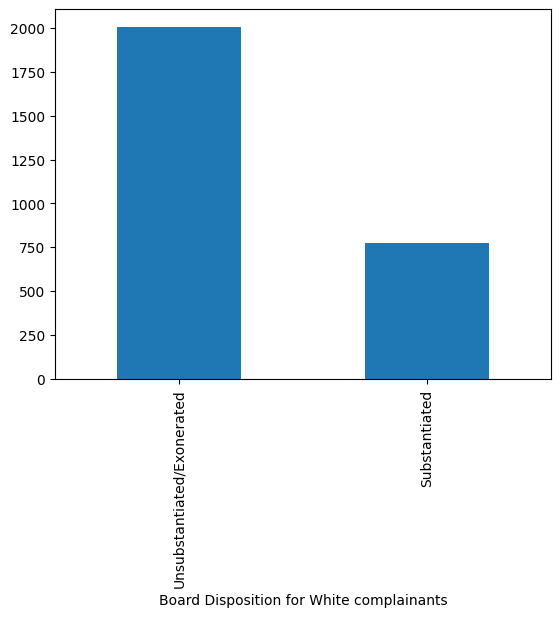

In [12]:
graph_maker('White')

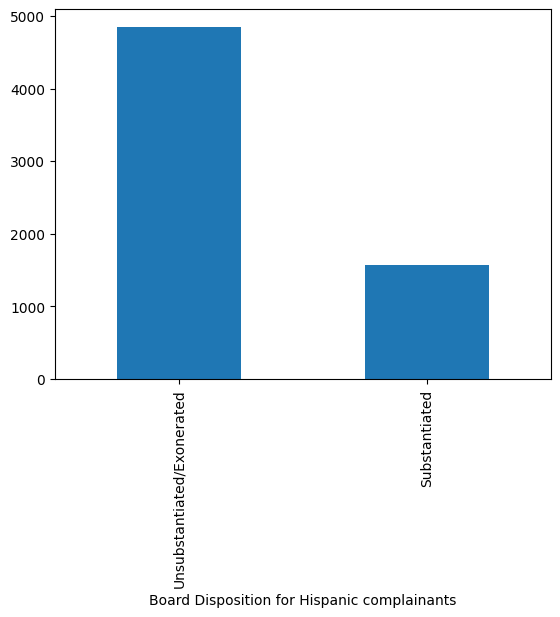

In [13]:
graph_maker('Hispanic')

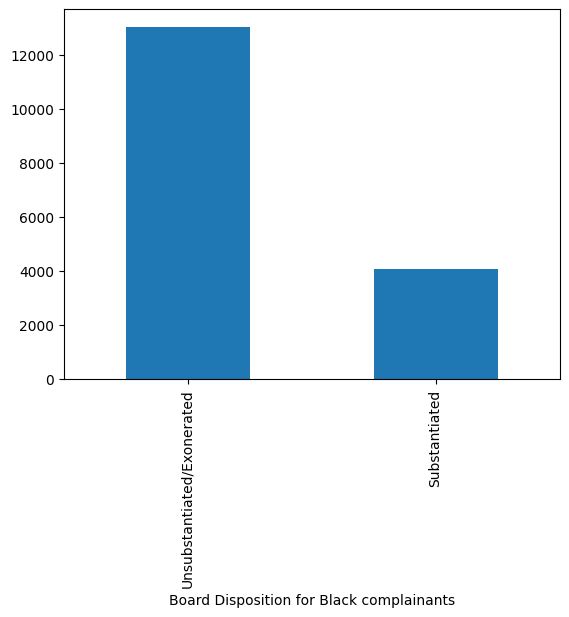

In [14]:
graph_maker('Black')

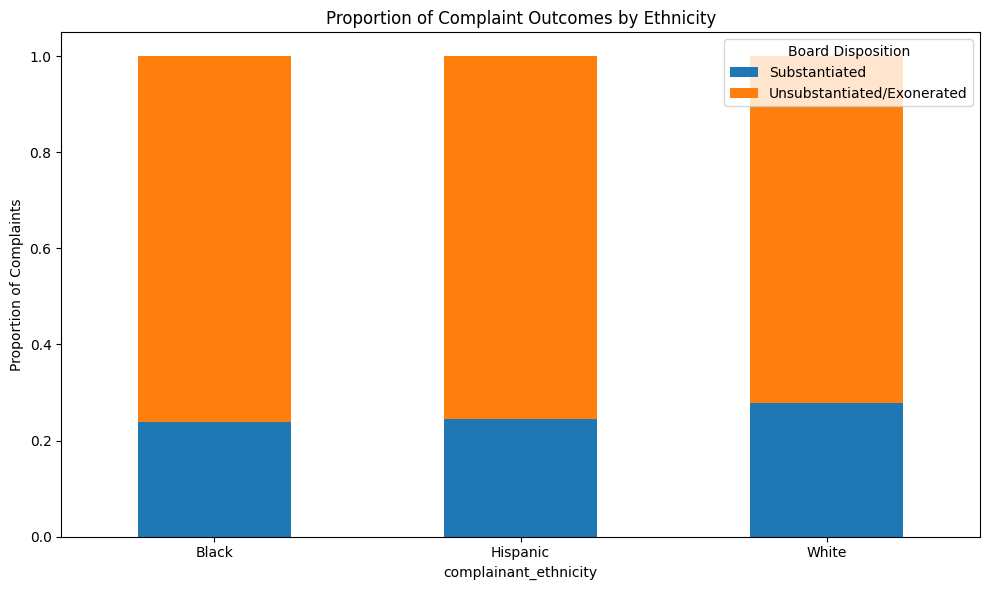

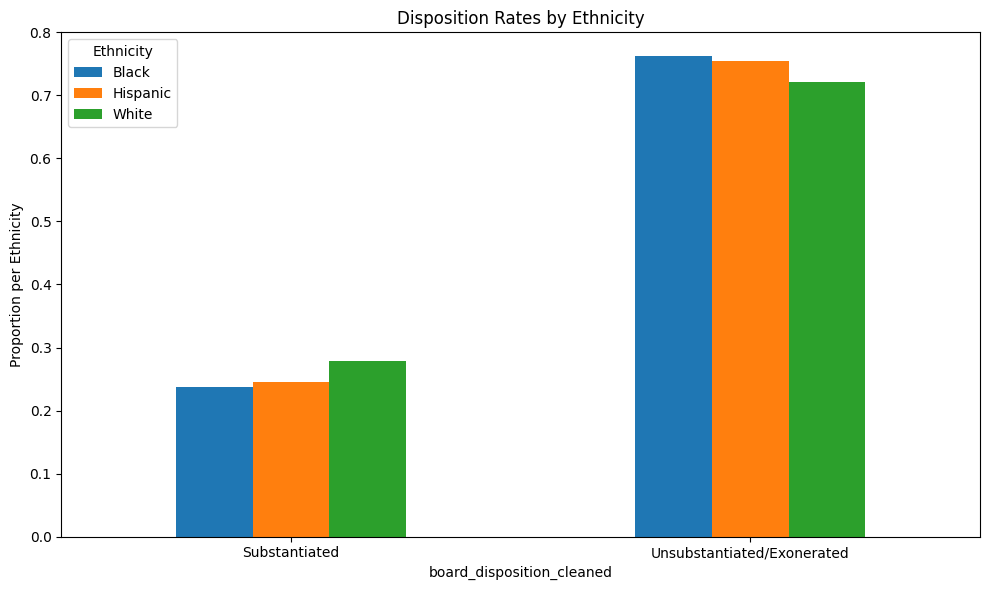

In [15]:
# Step 1: Filter and group
ethnicities = ['White', 'Hispanic', 'Black']
result = (
    allegations[allegations['complainant_ethnicity'].isin(ethnicities)]
    .groupby(['complainant_ethnicity', 'board_disposition_cleaned'])
    .size()
    .unstack(fill_value=0)
)

# Step 2: Normalize by row (i.e., total complaints per ethnicity)
normalized = result.div(result.sum(axis=1), axis=0)

# Step 3: Plot the normalized data
normalized.plot(kind='bar', figsize=(10, 6), stacked=True)
plt.ylabel("Proportion of Complaints")
plt.title("Proportion of Complaint Outcomes by Ethnicity")
plt.xticks(rotation=0)
plt.legend(title="Board Disposition")
plt.tight_layout()
plt.show()

normalized.T.plot(kind='bar', figsize=(10, 6))
plt.ylabel("Proportion per Ethnicity")
plt.title("Disposition Rates by Ethnicity")
plt.xticks(rotation=0)
plt.legend(title="Ethnicity")
plt.tight_layout()
plt.show()


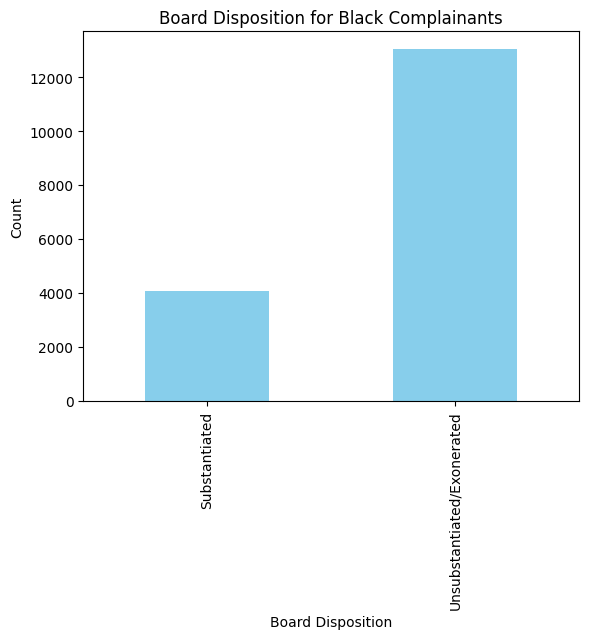

In [16]:
# Group by 'board_disposition_cleaned' for Black complainants and plot
black_complainant_disposition = allegations[allegations['complainant_ethnicity'] == 'Black'].groupby('board_disposition_cleaned').size()

black_complainant_disposition.plot(kind='bar', color='skyblue', title='Board Disposition for Black Complainants')
plt.xlabel('Board Disposition')
plt.ylabel('Count')
plt.show()

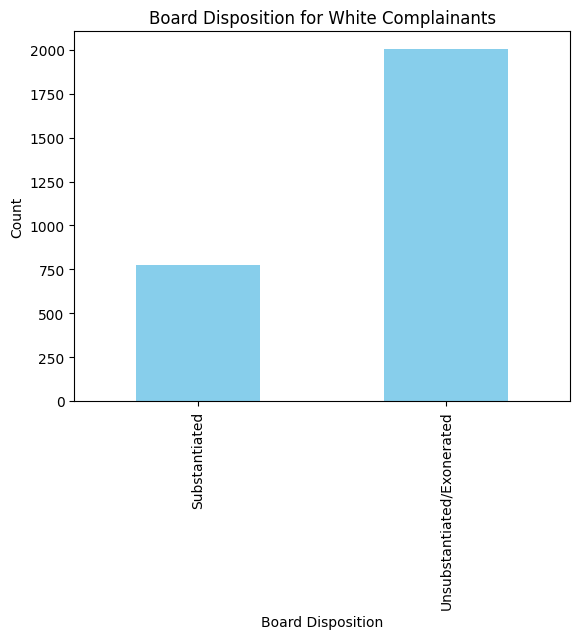

In [17]:
# Group by 'board_disposition_cleaned' for Black complainants and plot
black_complainant_disposition = allegations[allegations['complainant_ethnicity'] == 'White'].groupby('board_disposition_cleaned').size()

black_complainant_disposition.plot(kind='bar', color='skyblue', title='Board Disposition for White Complainants')
plt.xlabel('Board Disposition')
plt.ylabel('Count')
plt.show()

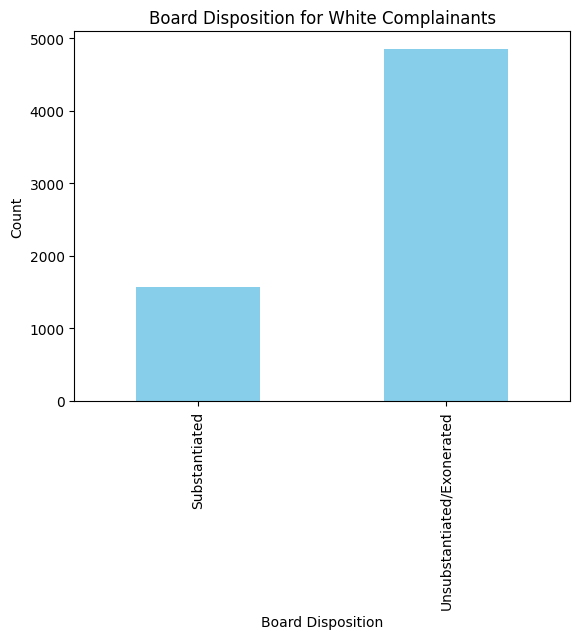

In [18]:
# Group by 'board_disposition_cleaned' for Black complainants and plot
black_complainant_disposition = allegations[allegations['complainant_ethnicity'] == 'Hispanic'].groupby('board_disposition_cleaned').size()

black_complainant_disposition.plot(kind='bar', color='skyblue', title='Board Disposition for White Complainants')
plt.xlabel('Board Disposition')
plt.ylabel('Count')
plt.show()

In [19]:
allegations[allegations['complainant_ethnicity'] == 'White'].groupby('board_disposition_cleaned').size().sort_values(ascending=False)

board_disposition_cleaned
Unsubstantiated/Exonerated    2006
Substantiated                  777
dtype: int64

In [20]:
allegations[allegations['complainant_ethnicity'] == 'Hispanic'].groupby('board_disposition_cleaned').size().sort_values(ascending=False)

board_disposition_cleaned
Unsubstantiated/Exonerated    4852
Substantiated                 1572
dtype: int64

In [21]:
allegations['complainant_ethnicity'].value_counts()

complainant_ethnicity
Black              17114
Hispanic            6424
White               2783
Unknown             1041
Other Race           677
Asian                532
Refused              259
American Indian       64
Name: count, dtype: int64

Text(0, 0.5, 'Rate of Substantiation')

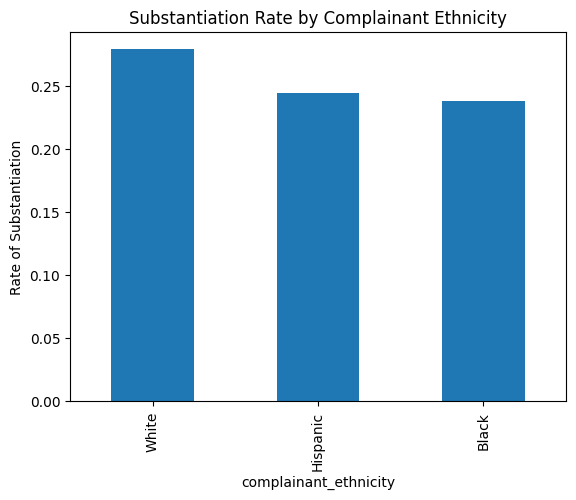

In [22]:
subst_rate = result['Substantiated'] / result.sum(axis=1)
subst_rate.sort_values(ascending=False).plot(kind='bar')
plt.title("Substantiation Rate by Complainant Ethnicity")
plt.ylabel("Rate of Substantiation")


In [24]:
#subst_rate = substantiation_rate["Substantiated"]
#subst_rate.sort_values(ascending=False).plot(kind='bar', color="#1f77b4", edgecolor="black")

#plt.title("Substantiation Rate by Complainant Ethnicity")
#plt.ylabel("Rate of Substantiation")
#plt.ylim(0.17, 0.30)
#plt.xticks(rotation=0)
#plt.tight_layout()
#plt.show()

In [30]:
# # Group all substantiated outcomes under a single label "Substantiated"
# allegations["board_disposition_simplified"] = allegations["board_disposition_cleaned"].replace(
#     to_replace=r"^Substantiated.*", value="Substantiated", regex=True
# )

# # Re-run the breakdown and normalization with simplified outcomes
# filtered = allegations[allegations["complainant_ethnicity"].isin(target_ethnicities)]

# substantiation_rate = (
#     filtered.groupby("complainant_ethnicity")["board_disposition_simplified"]
#     .value_counts(normalize=True)
#     .unstack(fill_value=0)
# )

# substantiation_counts = (
#     filtered.groupby("complainant_ethnicity")["board_disposition_simplified"]
#     .value_counts()
#     .unstack(fill_value=0)
# )

# substantiation_rate, substantiation_counts


# # Plot substantiation rates (grouped bar chart)
# substantiation_rate[["Substantiated", "Unsubstantiated", "Exonerated"]].plot(
#     kind='bar',
#     figsize=(10, 6),
#     color=["#1f77b4", "#ff7f0e", "#2ca02c"],
#     edgecolor="black"
# )

# plt.title("Complaint Outcomes by Complainant Ethnicity")
# plt.ylabel("Proportion of Complaints")
# plt.xlabel("Complainant Ethnicity")
# plt.xticks(rotation=0)
# plt.ylim(0.23, 0.3)
# plt.legend(title="Outcome")
# plt.tight_layout()
# plt.show()

In [28]:
# #substantiation_rate[["Substantiated", "Unsubstantiated", "Exonerated"]].T.plot(kind='bar', figsize=(10, 6))
# plt.ylabel("Proportion per Ethnicity")
# plt.title("Disposition Rates by Ethnicity")
# plt.xticks(rotation=0)
# plt.legend(title="Ethnicity")
# plt.tight_layout()
# plt.ylim(0.23, 0.5)
# plt.show()

In [33]:
allegations

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition,board_disposition_cleaned,board_disposition_simplified
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions),Substantiated,Substantiated
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Substantiated,Substantiated
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Substantiated,Substantiated
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges),Substantiated,Substantiated
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A),Substantiated,Substantiated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33353,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Discourtesy,Word,66.0,Moving violation,Moving violation summons issued,Unsubstantiated,Unsubstantiated/Exonerated,Unsubstantiated/Exonerated
33354,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Interference with recording,66.0,Moving violation,Moving violation summons issued,Unsubstantiated,Unsubstantiated/Exonerated,Unsubstantiated/Exonerated
33355,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Search (of person),66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training),Substantiated,Substantiated
33356,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Vehicle search,66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training),Substantiated,Substantiated


nan

In [99]:
allegations_eth_cln = allegations.copy()
allegations_eth_cln['complainant_ethnicity'].replace({
     'Other Race': 'N/A',
     'Unknown': 'N/A',
     'Refused': 'N/A',
     allegations['complainant_ethnicity'].iloc[4]: 'N/A',
     'NA': 'N/A'
 }, inplace=True
 )

allegations_eth_cln['complainant_ethnicity'].replace({
    'N/A': 'Unavailable/Other'
 }, inplace=True
 )

/var/folders/h3/f3_68x516pj6d7h2119r5st00000gn/T/ipykernel_95634/2620728608.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  allegations_eth_cln['complainant_ethnicity'].replace({


In [87]:
allegations_eth_cln['complainant_ethnicity'].unique()

array(['Black', 'N/A', 'White', 'Asian', 'Hispanic', 'American Indian'],
      dtype=object)

In [47]:
allegations_eth_cln = allegations.copy()


array(['Black', nan, 'White', 'Asian', 'Refused', 'Hispanic', 'Unknown',
       'Other Race', 'American Indian'], dtype=object)

In [54]:
allegations

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition,board_disposition_cleaned,board_disposition_simplified
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions),Substantiated,Substantiated
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Substantiated,Substantiated
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Substantiated,Substantiated
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges),Substantiated,Substantiated
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A),Substantiated,Substantiated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33353,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Discourtesy,Word,66.0,Moving violation,Moving violation summons issued,Unsubstantiated,Unsubstantiated/Exonerated,Unsubstantiated/Exonerated
33354,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Interference with recording,66.0,Moving violation,Moving violation summons issued,Unsubstantiated,Unsubstantiated/Exonerated,Unsubstantiated/Exonerated
33355,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Search (of person),66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training),Substantiated,Substantiated
33356,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,Male,21.0,Abuse of Authority,Vehicle search,66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training),Substantiated,Substantiated


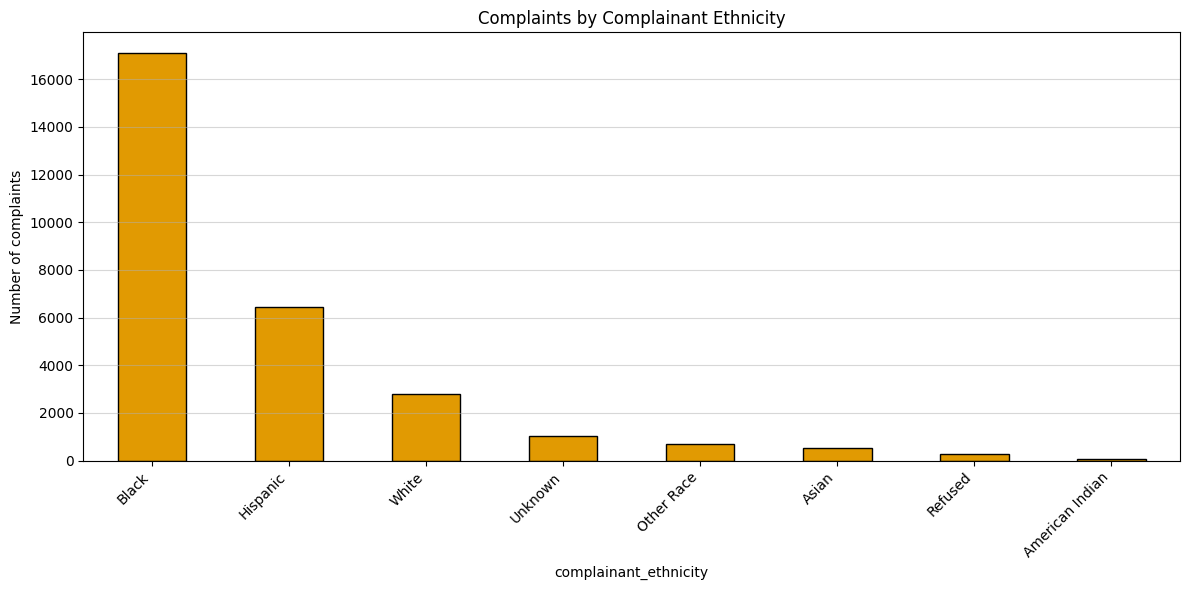

In [52]:
# Visualize complaint counts by complainant ethnicity
ethnicity_order = [
    'Black',
    'Hispanic',
    'White',
    'Unknown',
    'Other Race',
    'Asian',
    'Refused',
    'American Indian'
]
complaints_by_ethnicity = (
    allegations['complainant_ethnicity']
    .value_counts()
    .reindex(ethnicity_order, fill_value=0)
)
ax = complaints_by_ethnicity.plot(
    kind='bar',
    color='#E19A02',
    edgecolor='black',
    figsize=(12, 6)
)
ax.set_title('Complaints by Complainant Ethnicity')
ax.set_xlabel('complainant_ethnicity')
ax.set_ylabel('Number of complaints')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

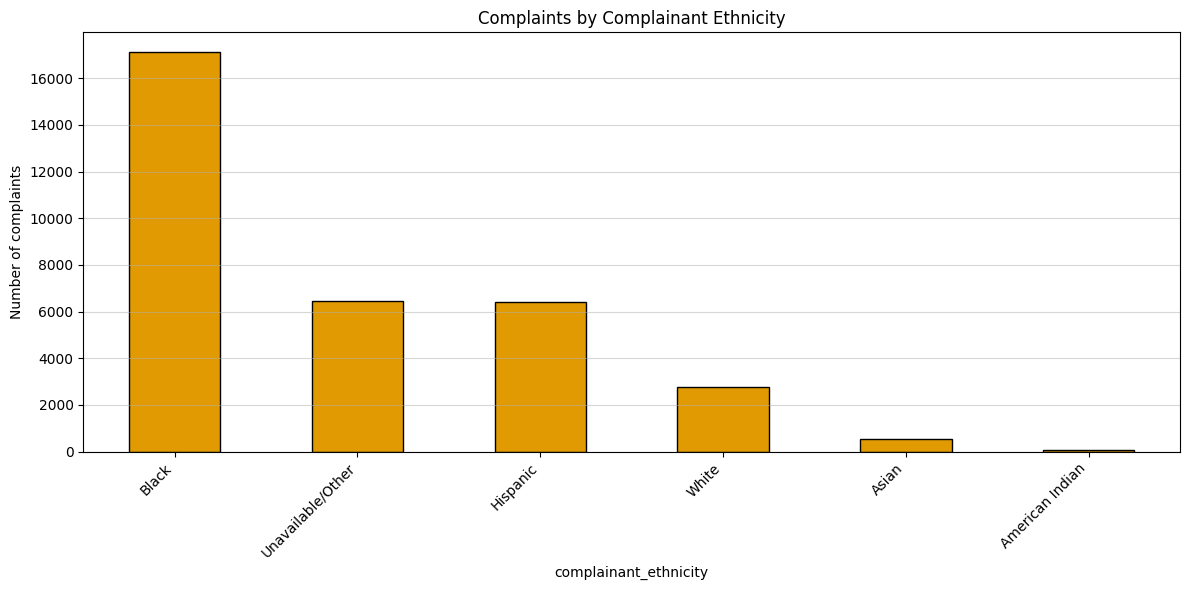

<Figure size 640x480 with 0 Axes>

In [ ]:
ethnicity_order = ['Black','Unavailable/Other', 'Hispanic', 'White', 'Asian', 'American Indian']
complaints_by_ethnicity = (
    allegations_eth_cln['complainant_ethnicity']
    .value_counts()
    .reindex(ethnicity_order, fill_value=0)
)
ax = complaints_by_ethnicity.plot(
    kind='bar',
    color='#E19A02',
    edgecolor='black',
    figsize=(12, 6)
)
ax.set_title('Complaints by Complainant Ethnicity')
ax.set_xlabel('Complainant Ethnicity')
ax.set_ylabel('Number of complaints')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('Complaints by Complainant Ethnicity')

*Figure:* CCRB complaint counts by complainant ethnicity, with Black complainants filing the most complaints.